# Cyclistic Bike-Share Case Study
### Google Data Analytics Capstone

**Business Task:** Analyze historical Cyclistic trip data to identify how annual members and casual riders use bikes differently, to inform a marketing strategy that converts casual riders into annual members.

**Data source:** Divvy Trip Data (Aug 2025 - Jul 2026), made available by Motivate International Inc.


## Setup

**What this cell does:**
- Import the pandas and numpy libraries, which are the main tools for working with tables of data.
- Import glob and os for working with file paths and folders.
- The pd.set_option() tells pandas not to hide any columns when it prints a table.


In [30]:
import pandas as pd
import numpy as np
import glob
import os

pd.set_option('display.max_columns', None)


**What this cell does:**
- Created a 'DATA_FOLDER' variable that stores the folder with the raw CSV files.
- csv_files uses `glob.glob(os.path.join(DATA_FOLDER, "**", "*.csv"))` to search in 'DATA_FOLDER' (raw_data) for every subfolder and find anything ending in .csv.
-  Print a list of their file paths.

In [31]:
DATA_FOLDER = "raw_data"

csv_files = glob.glob(os.path.join(DATA_FOLDER, "**", "*.csv"), recursive=True)
csv_files = sorted(csv_files)

print("Found", len(csv_files), "files:")
for file_path in csv_files:
    print(" -", os.path.basename(file_path))


Found 12 files:
 - 202501-divvy-tripdata.csv
 - 202508-divvy-tripdata.csv
 - 202509-divvy-tripdata.csv
 - 202510-divvy-tripdata.csv
 - 202511-divvy-tripdata.csv
 - 202512-divvy-tripdata.csv
 - 202602-divvy-tripdata.csv
 - 202603-divvy-tripdata.csv
 - 202604-divvy-tripdata.csv
 - 202605-divvy-tripdata.csv
 - 202606-divvy-tripdata.csv
 - 202607-divvy-tripdata.csv


**What this cell does:**

- Make sure all the files have the same columns before combining them into one. 
- Created an empty list called column_lists to store the column names from each file.
- The for loop goes through every file path, grabs the column names, and adds them to the list
- The second for loop compares every file's columns to the first file's columns and prints a warning if any don't match.
- If nothing prints in that loop, then every file matched.


In [32]:
column_lists = []

for file_path in csv_files:
    columns_in_this_file = list(pd.read_csv(file_path, nrows=0).columns)
    column_lists.append(columns_in_this_file)

first_file_columns = column_lists[0]

all_match = True
for i in range(len(csv_files)):
    if column_lists[i] != first_file_columns:
        all_match = False
        print("Mismatch found in:", os.path.basename(csv_files[i]))
        print("  Its columns:", column_lists[i])

if all_match:
    print("All 12 files have matching columns.")


All 12 files have matching columns.


**What this cell does:**

- Created an empty list `dataframes` to hold each month's data table.
- The for loop reads each CSV file into a DataFrame and adds it to our list.
- `pd.concat(dataframes, ignore_index=True)` stacks all 12 DataFrames into one big DataFrame. `ignore_index=True` renumbers the rows from 0 instead of restarting the count for every month.
- Check the first 5 rows with `df.head()` 

In [33]:
dataframes = []

for file_path in csv_files:
    monthly_data = pd.read_csv(file_path)
    dataframes.append(monthly_data)

df = pd.concat(dataframes, ignore_index=True)

df.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member


## Cleaning and Transforming data

**What this cell does**
- checking the data for consistency
- `df.dtypes` shows the data type of each column.
- `df.isna().sum()` counts how many blank/missing values are in each column.
- `df['ride_id'].duplicated().sum()` counts how many rows have a duplicate ride_id.
- `df['member_casual'].unique()` and `df['rideable_type'].unique()` list out every distinct value in those columns.


In [ ]:
print("Data types:")
print(df.dtypes)
print()

print("Missing values per column:")
print(df.isna().sum())
print()

print("Duplicate ride_ids:", df['ride_id'].duplicated().sum())
print()

print("member_casual unique values:", df['member_casual'].unique())
print("rideable_type unique values:", df['rideable_type'].unique())


Data types:
ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

Missing values per column:
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1273200
start_station_id      1273200
end_station_name      1336777
end_station_id        1336777
start_lat                   0
start_lng                   0
end_lat                  5436
end_lng                  5436
member_casual               0
dtype: int64

Duplicate ride_ids: 35

member_casual unique values: <StringArray>
['member', 'casual']
Length: 2, dtype: str
rideable_type unique values: <StringArray>

**What this cell does**

- `pd.to_datetime()` converts the text columns into actual datetime values for both started_at and ended_at.
- `ride_length` subtracts two datetimes to give a duration converted to minutes.
- Built a dictionary to re-map pandas' numbering convention to the case study requirement.
- `.dt.month_name()` pulls out the full month name.


In [ ]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

weekday_map = {
    0: 2,  # Monday -> 2
    1: 3,  # Tuesday -> 3
    2: 4,  # Wednesday -> 4
    3: 5,  # Thursday -> 5
    4: 6,  # Friday -> 6
    5: 7,  # Saturday -> 7
    6: 1,  # Sunday -> 1
}
df['day_of_week'] = df['started_at'].dt.dayofweek.map(weekday_map)

df['month'] = df['started_at'].dt.month_name()

df.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week,month
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,15.021400,7,January
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,7.605467,5,January
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,6.739167,3,January
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,30.836433,2,January
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,78.447200,7,January


**What this cell does**
- checking for problem rows before deleting anything
- `df['ride_length'] <= 0` flags rides with zero or negative length (data entry errors). 
- `df['ride_length'] > 1440` flags rides longer than 24 hours (likely a bike not properly docked).
- Also count missing station names, added together for start and end.


In [ ]:
negative_or_zero_count = (df['ride_length'] <= 0).sum()
too_long_count = (df['ride_length'] > 1440).sum()
missing_station_count = df['start_station_name'].isna().sum() + df['end_station_name'].isna().sum()

print("Rides with ride_length <= 0 minutes:", negative_or_zero_count)
print("Rides longer than 24 hours (1440 min):", too_long_count)
print("Rows with a missing station name (start or end):", missing_station_count)


Rides with ride_length <= 0 minutes: 29
Rides longer than 24 hours (1440 min): 5341
Rows with a missing station name (start or end): 2609977


**What this cell does**

- `before_count = len(df)` saves the row count before cleaning.
- `keep_this_row` keeps only good rows that pass both quality checks.
- `.drop_duplicates(subset='ride_id', keep='first')` removes repeat ride_ids.
- We print how many rows were removed and what percentage that represents.

In [ ]:
before_count = len(df)

keep_this_row = (df['ride_length'] > 0) & (df['ride_length'] <= 1440)
df_clean = df[keep_this_row].copy()

df_clean = df_clean.drop_duplicates(subset='ride_id', keep='first')

after_count = len(df_clean)
removed_count = before_count - after_count
removed_percent = removed_count / before_count

print("Rows before cleaning:", before_count)
print("Rows removed:", removed_count, f"({removed_percent:.2%} of data)")
print("Rows remaining:", after_count)


Rows before cleaning: 6037968
Rows removed: 5398 (0.09% of data)
Rows remaining: 6032570


In [ ]:
os.makedirs("cleaned_data", exist_ok=True)
df_clean.to_csv("cleaned_data/cyclistic_cleaned.csv", index=False)
print("Saved cleaned_data/cyclistic_cleaned.csv")


Saved cleaned_data/cyclistic_cleaned.csv


## Analysis

In [10]:
df_clean.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'max', 'min', 'count'])


,mean,median,max,min,count
member_casual,,,,,
casual,18.261326,11.034383,1439.975950,0.000767,2146699
member,12.011467,8.573100,1439.901683,0.001233,3885871


In [11]:
pd.pivot_table(
    df_clean,
    values='ride_length',
    index='member_casual',
    columns='day_of_week',
    aggfunc='mean'
)


day_of_week,1,2,3,4,5,6,7
member_casual,,,,,,,
casual,21.211678,18.291028,15.715448,15.177872,15.855913,17.751130,20.716571
member,13.166567,11.693491,11.563191,11.521452,11.562986,11.929502,13.220143


In [12]:
pd.pivot_table(
    df_clean,
    values='ride_id',
    index='member_casual',
    columns='day_of_week',
    aggfunc='count'
)


day_of_week,1,2,3,4,5,6,7
member_casual,,,,,,,
casual,356388,243861,237777,245787,267336,339142,456408
member,415163,538584,614191,622773,619329,581398,494433


In [13]:
pd.pivot_table(
    df_clean,
    values='ride_id',
    index='member_casual',
    columns='month',
    aggfunc='count'
)


month,April,August,December,February,January,July,June,March,May,November,October,September
member_casual,,,,,,,,,,,,
casual,131223,337246,28005,41088,24656,357111,307873,87631,244654,98871,223569,264772
member,316675,452355,112415,160251,112933,511171,454025,229121,408510,257292,421921,449202


In [14]:
pd.pivot_table(
    df_clean,
    values='ride_id',
    index='member_casual',
    columns='rideable_type',
    aggfunc='count'
)


rideable_type,classic_bike,electric_bike
member_casual,,
casual,607966,1538733
member,1277906,2607965


## Visualizations

In [15]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('outputs', exist_ok=True)


### Chart 1: Average ride length by rider type


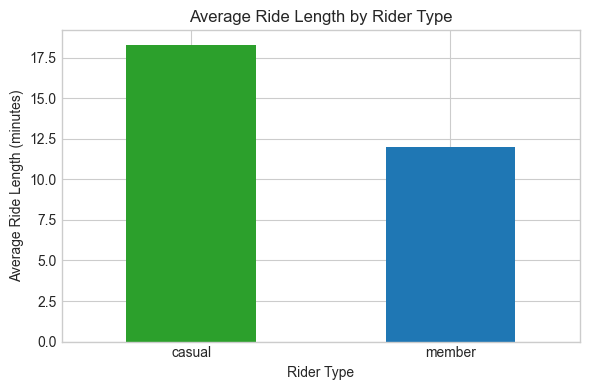

In [16]:
avg_length = df_clean.groupby('member_casual')['ride_length'].mean()

avg_length.plot(kind='bar', color=['#2ca02c', '#1f77b4'], figsize=(6, 4))
plt.title('Average Ride Length by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Average Ride Length (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/chart1_avg_ride_length.png', dpi=150)
plt.show()


### Chart 2: Number of rides by day of week, by rider type

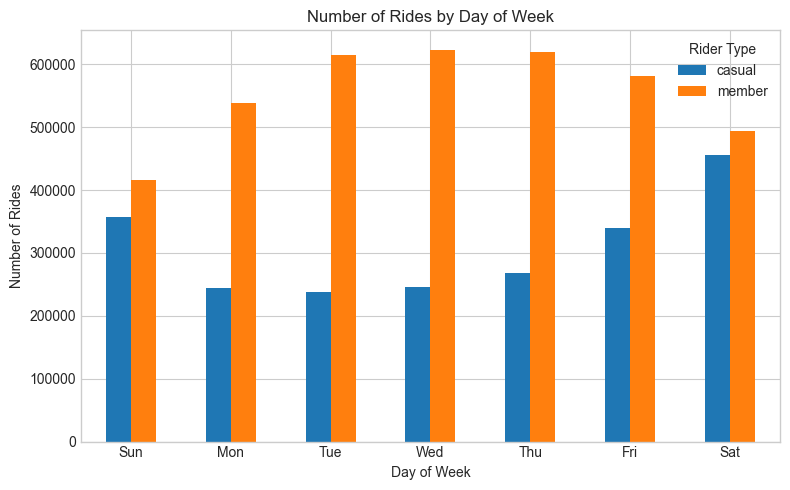

In [17]:
rides_by_day = pd.pivot_table(
    df_clean,
    values='ride_id',
    index='member_casual',
    columns='day_of_week',
    aggfunc='count'
)

day_labels = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
rides_by_day = rides_by_day.rename(columns=day_labels)

rides_by_day.T.plot(kind='bar', figsize=(8, 5))
plt.title('Number of Rides by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.legend(title='Rider Type')
plt.tight_layout()
plt.savefig('outputs/chart2_rides_by_day.png', dpi=150)
plt.show()


### Chart 3: Number of rides by month, by rider type

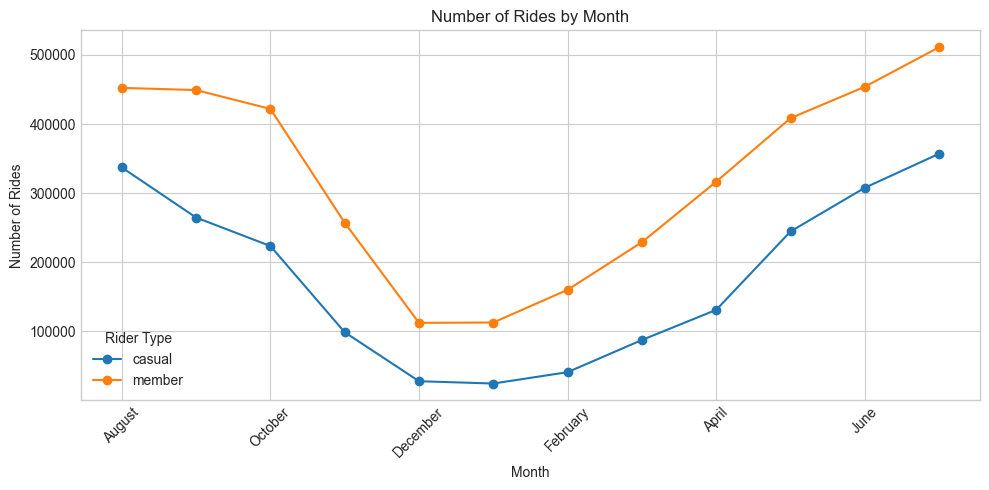

In [18]:
rides_by_month = pd.pivot_table(
    df_clean,
    values='ride_id',
    index='member_casual',
    columns='month',
    aggfunc='count'
)

month_order = ['August', 'September', 'October', 'November', 'December',
               'January', 'February', 'March', 'April', 'May', 'June', 'July']
rides_by_month = rides_by_month.reindex(columns=month_order)

rides_by_month.T.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Number of Rides by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Rider Type')
plt.tight_layout()
plt.savefig('outputs/chart3_rides_by_month.png', dpi=150)
plt.show()


### Chart 4: Bike type usage by rider type

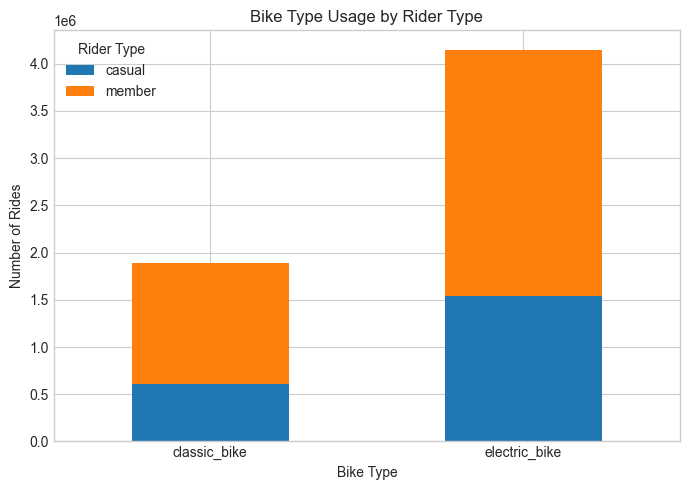

In [19]:
rides_by_bike_type = pd.pivot_table(
    df_clean,
    values='ride_id',
    index='rideable_type',
    columns='member_casual',
    aggfunc='count'
)

rides_by_bike_type.plot(kind='bar', stacked=True, figsize=(7, 5))
plt.title('Bike Type Usage by Rider Type')
plt.xlabel('Bike Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.legend(title='Rider Type')
plt.tight_layout()
plt.savefig('outputs/chart4_bike_type.png', dpi=150)
plt.show()


## Top Recommendations



Based on the analysis above, three clear differences emerged between casual riders and annual members: casual riders take longer rides, concentrate their usage on weekends, and drop off far more sharply in winter. The following recommendations target converting casual riders into annual members by addressing these specific patterns:

1. Weekend-to-Weekday Membership Push
Casual ridership peaks sharply on Saturdays and Sundays, while members ride steadily across weekdays. This suggests casual riders view Cyclistic as a weekend leisure activity rather than a daily tool. A targeted campaign — delivered via app notification or email immediately after a weekend ride — should reframe membership not just as "better value for weekend riding," but as a gateway to affordable weekday commuting the rider hasn't tried yet. Testing both a savings - focused message and a lifestyle - focused message would clarify which angle converts better.

2. Seasonal Membership Incentive Before the Winter Drop-Off
Casual ridership falls roughly 88% from its summer peak to its winter low — a much steeper decline than members experience (~76%). This indicates casual riders are highly weather-sensitive and largely inactive for several months. Offering a discounted or trial annual membership in the shoulder months (September–October) framed as "lock in your rate before it goes up" could capture riders while they're still active, encouraging them to commit before they naturally stop riding for the season.

3. Ride-Based Triggered Offers for High-Frequency Casual Riders
Not all casual riders behave the same way. Riders who log multiple rides within a short window (e.g., 3+ rides in 30 days) are already exhibiting member-like behavior and represent the highest-probability conversion targets. Personalized offers — such as showing a rider how much they've spent on single-ride passes compared to the cost of an annual membership — would be more effective than broad, one-size-fits-all marketing. Given casual riders' modest preference for electric bikes, highlighting guaranteed electric bike access as a membership perk may further strengthen this pitch.